# Theorem 7: Universal Approximation by Linear Continuous-Time RNNs

## Notebook abstract

This notebook gives a mathematically guided numerical illustration of Theorem 7 in Li, Han, E, and Li (2022).

The notebook is organized around three experimental questions:

1. Can exponential-sum kernels approximate representative admissible target kernels?
2. How much is gained by learning the decay rates instead of fixing them?
3. Does a small kernel error lead to small errors in the induced functionals?

The notebook distinguishes carefully between:

- results proved in Li et al.;
- numerical implementation choices;
- empirical observations;
- limitations of the experiments.

## Citation and scope

Z. Li, J. Han, W. E, and Q. Li, “Approximation and Optimization Theory for Linear Continuous-Time Recurrent Neural Networks,” *Journal of Machine Learning Research*, vol. 23, no. 42, pp. 1–85, 2022.

JMLR article identifier: **21-0368**.

The notation and theorem numbering below follow the published JMLR version. The experiments are illustrations of the approximation mechanism and are not proofs of Theorem 7.

## 1. Functional setting

The input space is

$$
\mathcal X=C_0(\mathbb R,\mathbb R^d),
$$

equipped with

$$
\|x\|_{\mathcal X}
=
\sup_{t\in\mathbb R}\|x_t\|_\infty.
$$

For each time \(t\in\mathbb R\), the target is a functional

$$
H_t:\mathcal X\to\mathbb R.
$$

Li et al. assume that the family \(\{H_t\}_{t\in\mathbb R}\) is continuous and linear, causal, regular, and time-homogeneous.

Under these assumptions, Theorem 7 states that for every \(\varepsilon>0\), there exists a stable linear continuous-time RNN functional \(\widehat H_t\) such that

$$
\sup_{t\in\mathbb R}
\sup_{\|x\|_{\mathcal X}\le 1}
|H_t(x)-\widehat H_t(x)|
\le \varepsilon.
$$

*Source: Li et al. (2022), Definitions 2–5 and Theorem 7.*

## 2. Kernel representation

Lemma 15 shows that the assumptions above imply the existence of an integrable kernel

$$
\rho:[0,\infty)\to\mathbb R^d,
\qquad
\rho\in L^1([0,\infty),\mathbb R^d),
$$

such that

$$
H_t(x)
=
\int_0^\infty x_{t-s}^{\top}\rho(s)\,ds.
$$

A stable linear continuous-time RNN satisfies

$$
\dot h_t=Wh_t+Ux_t,
\qquad
\widehat y_t=c^\top h_t,
$$

and induces

$$
\widehat H_t(x)
=
\int_0^\infty
x_{t-s}^{\top}
\left(U^\top e^{W^\top s}c\right)\,ds.
$$

Hence the RNN kernel is

$$
\widehat\rho(s)=U^\top e^{W^\top s}c.
$$

> **Mathematical idea.**  
> The infinite-dimensional functional approximation problem is reduced to approximation of a single convolution kernel in \(L^1\).

*Source: Li et al. (2022), equations (18), (20), (23), and Lemma 15.*

## 3. Why the \(L^1\)-kernel error is the relevant quantity

For every \(x\in\mathcal X\),

$$
\begin{aligned}
|H_t(x)-\widehat H_t(x)|
&=
\left|
\int_0^\infty
x_{t-s}^{\top}
\bigl(\rho(s)-\widehat\rho(s)\bigr)\,ds
\right|\\
&\le
\|x\|_{\mathcal X}
\|\rho-\widehat\rho\|_{L^1}.
\end{aligned}
$$

Therefore,

$$
\sup_{t\in\mathbb R}
\sup_{\|x\|_{\mathcal X}\le 1}
|H_t(x)-\widehat H_t(x)|
\le
\|\rho-\widehat\rho\|_{L^1}.
$$

The kernel error is thus stronger than testing a finite collection of input paths.

*Source: Li et al. (2022), equation (62).*

## 4. Relation to the proof of Theorem 7

The proof in Li et al. first shows that every integrable scalar kernel can be approximated in \(L^1\) by a function of the form

$$
p(e^{-t}),
\qquad
p(0)=0.
$$

If

$$
p(u)=\sum_{j=1}^m \alpha_j u^j,
$$

then

$$
p(e^{-t})
=
\sum_{j=1}^m \alpha_j e^{-jt}.
$$

This corresponds to

$$
W=\operatorname{diag}(-1,-2,\ldots,-m).
$$

The numerical model used below is the related diagonal-RNN class

$$
\widehat\rho_m(t)
=
\sum_{j=1}^m a_j e^{-\lambda_j t},
\qquad
\lambda_j>0.
$$

The paper's constructive proof uses the special rates \(\lambda_j=j\). The fixed logarithmic grid and the learned-rate model below are numerical extensions.

*Source: Li et al. (2022), Lemma 16 and equations (52), (60), and (61).*

### Map to the paper

| Notebook object | Paper location | Role |
|---|---:|---|
| Linear CT-RNN | equation (17) | model definition |
| RNN convolution representation | equation (18) | identifies the RNN kernel |
| RNN hypothesis class | equation (20) | defines \(\widehat{\mathcal H}\) |
| Universal approximation theorem | Theorem 7, equation (22) | target statement |
| Target kernel representation | equation (23), Lemma 15 | reduction to kernels |
| Density of \(p(e^{-t})\) | Lemma 16, equation (52) | approximation ingredient |
| Explicit diagonal realization | equations (60)–(61) | constructs the RNN |
| Functional error estimate | equation (62) | converts kernel error to operator error |

## 5. Import the experiment implementation

The notebook imports the reproducible implementation from

```text
experiments/03_theorem7_universal_approximation.py
```

so the notebook and the experiment script use the same functions.

In [1]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

experiment_path = (
    PROJECT_ROOT
    / "experiments"
    / "03_theorem7_universal_approximation.py"
)

if not experiment_path.exists():
    raise FileNotFoundError(
        f"Could not find {experiment_path}. "
        "Start Jupyter from the repository root or notebooks/."
    )

spec = importlib.util.spec_from_file_location(
    "theorem7_experiment",
    experiment_path,
)
exp = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(exp)

print(f"Imported: {experiment_path}")

Imported: /Users/eduard/Desktop/Studium/Code/ct-rnn-memory-kernels/experiments/03_theorem7_universal_approximation.py


## 6. Representative target kernels

We use two targets.

### Multiscale exponential kernel

$$
\rho_{\mathrm{multi}}(t)
=
0.6e^{-0.3t}
+
0.3e^{-2t}
+
0.1e^{-8t}.
$$

This kernel lies exactly in the finite exponential-sum model class. It is therefore a sanity check: with suitable learned rates, width \(m=3\) is sufficient for exact recovery up to floating-point error.

### Polynomially decaying kernel

$$
\rho_{\mathrm{poly}}(t)
=
\frac{1}{(1+t)^2}.
$$

This kernel is integrable but is not represented exactly by a finite exponential sum of the chosen form. It is the more informative universal-approximation example.

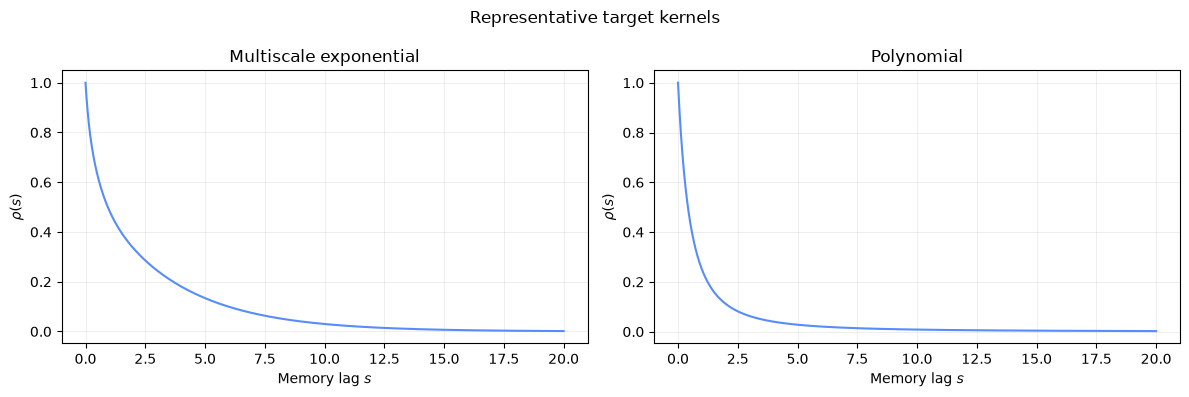

In [2]:
plot_grid = np.linspace(0.0, 20.0, 4000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

targets_to_plot = {
    "Multiscale exponential": exp.multiscale_exponential_kernel,
    "Polynomial": exp.polynomial_kernel,
}

for ax, (name, kernel_function) in zip(
    axes,
    targets_to_plot.items(),
):
    ax.plot(plot_grid, kernel_function(plot_grid))
    ax.set_title(name)
    ax.set_xlabel("Memory lag $s$")
    ax.set_ylabel(r"$\rho(s)$")
    ax.grid(alpha=0.3)

fig.suptitle("Representative target kernels")
fig.tight_layout()
plt.show()

**Figure 1.** Representative target kernels. The multiscale kernel belongs exactly to the finite exponential-sum model class, whereas the polynomial kernel illustrates approximation beyond exact finite representation.

## 7. Experiment 1: kernel approximation

For fixed rates \(\lambda_1,\ldots,\lambda_m\), define

$$
\Phi_{n,j}=e^{-\lambda_j t_n}.
$$

The coefficients solve

$$
a^\ast
\in
\operatorname*{argmin}_{a\in\mathbb R^m}
\|\Phi a-r\|_2^2.
$$

We restrict the main approximation plot to moderate widths to avoid mixing approximation behavior with the severe numerical ill-conditioning observed for very large fixed bases.

> **Numerical implementation.**  
> The coefficients are fitted on the training grid. The error is evaluated on a larger validation grid and supplemented by analytic tail bounds.

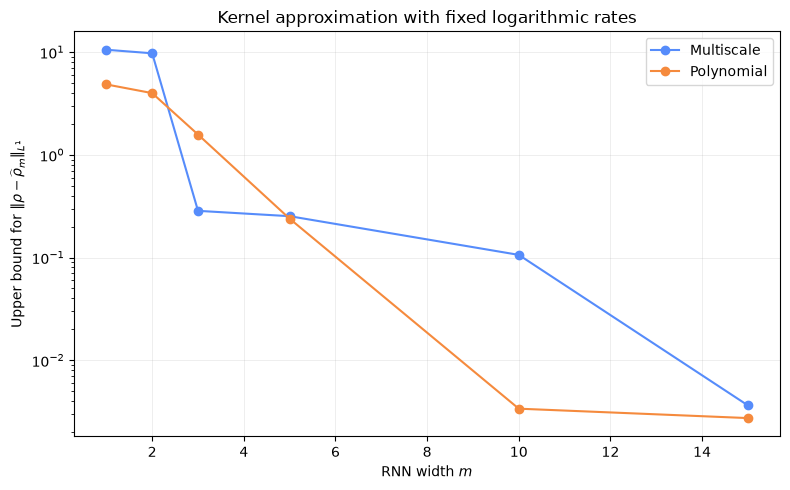

In [3]:
main_widths = [1, 2, 3, 5, 10, 15]

kernel_functions = {
    "Multiscale": exp.multiscale_exponential_kernel,
    "Polynomial": exp.polynomial_kernel,
}

fixed_error_results = {}

for kernel_name, kernel_function in kernel_functions.items():
    target_train = kernel_function(exp.t_train)
    errors = []

    for width in main_widths:
        rates = exp.decay_rates(width)
        basis = exp.exponential_basis(exp.t_train, rates)
        coefficients = exp.fit_coefficients(target_train, basis)

        total_bound = exp.full_l1_error_bound(
            kernel_name.lower(),
            kernel_function,
            coefficients,
            rates,
        )[-1]

        errors.append(total_bound)

    fixed_error_results[kernel_name] = errors

plt.figure(figsize=(8, 5))

for kernel_name, errors in fixed_error_results.items():
    plt.plot(
        main_widths,
        errors,
        marker="o",
        label=kernel_name,
    )

plt.xlabel("RNN width $m$")
plt.ylabel(r"Upper bound for $\|\rho-\widehat\rho_m\|_{L^1}$")
plt.title("Kernel approximation with fixed logarithmic rates")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 2.** \(L^1\)-error bounds for two representative target kernels using a fixed logarithmic rate grid. The plot is restricted to moderate widths because larger fixed bases become strongly ill-conditioned.

> **Interpretation.**  
> The polynomial target exhibits the intended approximation behavior: the error decreases as the model receives more exponential components. The multiscale target is not recovered exactly here because the fixed logarithmic grid does not necessarily contain the exact rates \(0.3\), \(2\), and \(8\).

## 8. Experiment 2: fixed versus learned decay rates

We now solve

$$
\min_{a\in\mathbb R^m,\;\lambda\in(0,\infty)^m}
\sum_{n=1}^N
\left(
\sum_{j=1}^m a_j e^{-\lambda_j t_n}
-
\rho(t_n)
\right)^2.
$$

The positivity condition is enforced by

$$
\lambda_j=e^{\theta_j},
\qquad
\theta_j\in\mathbb R.
$$

This changes the coordinates of the problem but not the admissible set of positive rates.

m= 1 | fixed=4.848e+00 | learned=3.088e-01
m= 2 | fixed=3.989e+00 | learned=1.138e-01
m= 3 | fixed=1.576e+00 | learned=5.077e-02
m= 5 | fixed=2.387e-01 | learned=1.461e-02
m=10 | fixed=3.372e-03 | learned=2.841e-03


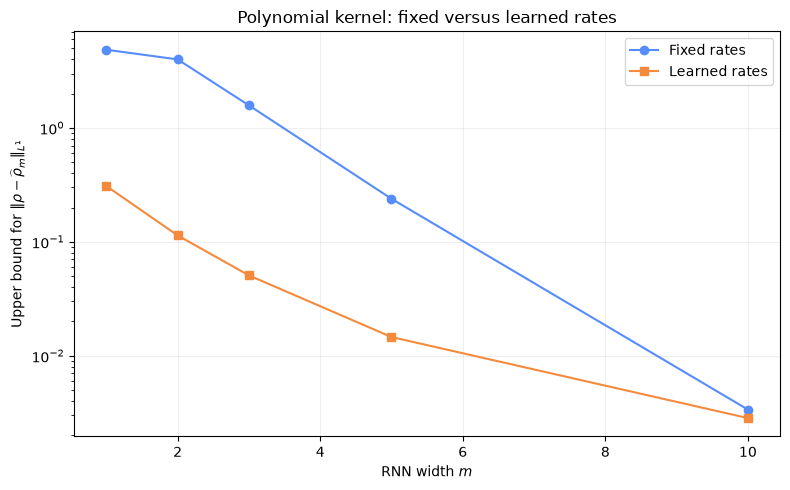

In [4]:
learned_widths = [1, 2, 3, 5, 10]
target_train = exp.polynomial_kernel(exp.t_train)

fixed_errors = []
learned_errors = []
learned_solutions = {}

for width in learned_widths:
    # Fixed rates
    fixed_rates = exp.decay_rates(width)
    fixed_basis = exp.exponential_basis(exp.t_train, fixed_rates)
    fixed_coefficients = exp.fit_coefficients(
        target_train,
        fixed_basis,
    )
    fixed_error = exp.full_l1_error_bound(
        "polynomial",
        exp.polynomial_kernel,
        fixed_coefficients,
        fixed_rates,
    )[-1]
    fixed_errors.append(fixed_error)

    # Learned rates
    learned_coefficients, learned_rates = (
        exp.fit_coefficients_and_rates(
            exp.t_train,
            target_train,
            width,
            max_nfev=1500,
        )
    )
    learned_error = exp.full_l1_error_bound(
        "polynomial",
        exp.polynomial_kernel,
        learned_coefficients,
        learned_rates,
    )[-1]

    learned_errors.append(learned_error)
    learned_solutions[width] = (
        learned_coefficients,
        learned_rates,
    )

    print(
        f"m={width:2d} | "
        f"fixed={fixed_error:.3e} | "
        f"learned={learned_error:.3e}"
    )

plt.figure(figsize=(8, 5))
plt.plot(
    learned_widths,
    fixed_errors,
    marker="o",
    label="Fixed rates",
)
plt.plot(
    learned_widths,
    learned_errors,
    marker="s",
    label="Learned rates",
)
plt.xlabel("RNN width $m$")
plt.ylabel(r"Upper bound for $\|\rho-\widehat\rho_m\|_{L^1}$")
plt.title("Polynomial kernel: fixed versus learned rates")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 3.** Comparison of fixed and learned decay rates for the polynomial target. Learning the rates adapts the available time scales to the target and can substantially improve the approximation at small and moderate widths.

Because the learned-rate problem is nonconvex, the attained error depends on initialization and is not guaranteed to decrease monotonically with width.

### Learned time scales

The next plot compares the fixed logarithmic grid with the rates learned for width \(m=10\).

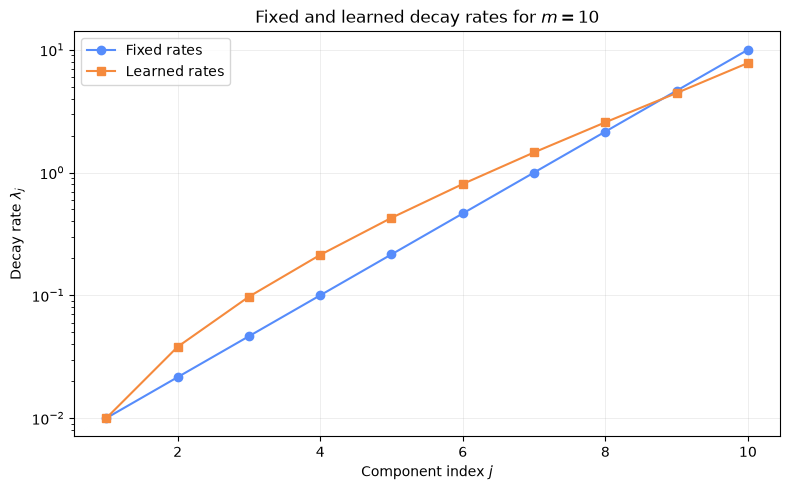

In [5]:
rate_width = 10

learned_coefficients, learned_rates = learned_solutions[rate_width]
fixed_rates = exp.decay_rates(rate_width)

indices = np.arange(1, rate_width + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    indices,
    fixed_rates,
    marker="o",
    label="Fixed rates",
)
plt.plot(
    indices,
    learned_rates,
    marker="s",
    label="Learned rates",
)
plt.xlabel("Component index $j$")
plt.ylabel(r"Decay rate $\lambda_j$")
plt.title("Fixed and learned decay rates for $m=10$")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 4.** Fixed and learned decay rates for the polynomial target. Small learned rates represent slowly decaying components and therefore longer time scales.

## 9. Numerical conditioning

For the basis matrix \(\Phi\), the spectral condition number is

$$
\kappa_2(\Phi)
=
\frac{\sigma_{\max}(\Phi)}
{\sigma_{\min}(\Phi)}.
$$

A large condition number indicates that some basis functions are nearly linearly dependent on the sampled interval. This can make the fitted coefficients highly sensitive to numerical perturbations.

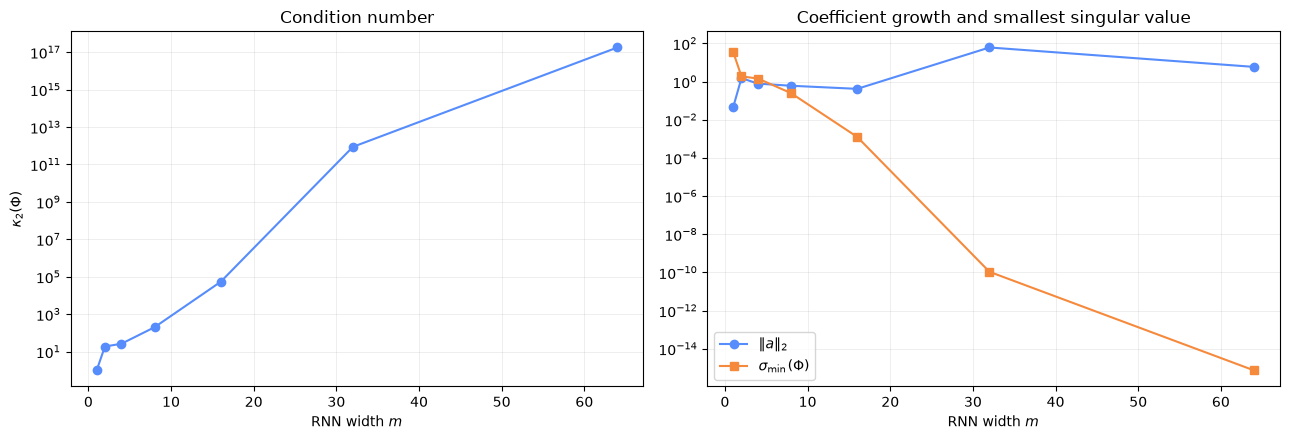

In [6]:
diagnostic_widths = [1, 2, 4, 8, 16, 32, 64]

condition_numbers = []
coefficient_norms = []
smallest_singular_values = []

target_train = exp.polynomial_kernel(exp.t_train)

for width in diagnostic_widths:
    rates = exp.decay_rates(width)
    basis = exp.exponential_basis(exp.t_train, rates)
    coefficients = exp.fit_coefficients(target_train, basis)

    condition_number, sigma_min, coefficient_norm = (
        exp.stability_diagnostics(
            basis,
            coefficients,
        )
    )

    condition_numbers.append(condition_number)
    smallest_singular_values.append(sigma_min)
    coefficient_norms.append(coefficient_norm)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(
    diagnostic_widths,
    condition_numbers,
    marker="o",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("RNN width $m$")
axes[0].set_ylabel(r"$\kappa_2(\Phi)$")
axes[0].set_title("Condition number")
axes[0].grid(alpha=0.3)

axes[1].plot(
    diagnostic_widths,
    coefficient_norms,
    marker="o",
    label=r"$\|a\|_2$",
)
axes[1].plot(
    diagnostic_widths,
    smallest_singular_values,
    marker="s",
    label=r"$\sigma_{\min}(\Phi)$",
)
axes[1].set_yscale("log")
axes[1].set_xlabel("RNN width $m$")
axes[1].set_title("Coefficient growth and smallest singular value")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

**Figure 5.** Numerical stability diagnostics for the fixed logarithmic basis. Increasing width enlarges the hypothesis class, but eventually creates a severely ill-conditioned discrete least-squares problem.

> **Interpretation.**  
> Nonmonotone errors at large widths are numerical artifacts of the chosen basis and solver, not contradictions of Theorem 7.

## 10. Input signals

We use three inputs in \(C_0(\mathbb R)\):

$$
x_1(t)=e^{-0.01t^2}\sin t,
$$

$$
x_2(t)=e^{-0.05|t|}\cos(0.5t),
$$

and a continuous triangular pulse.

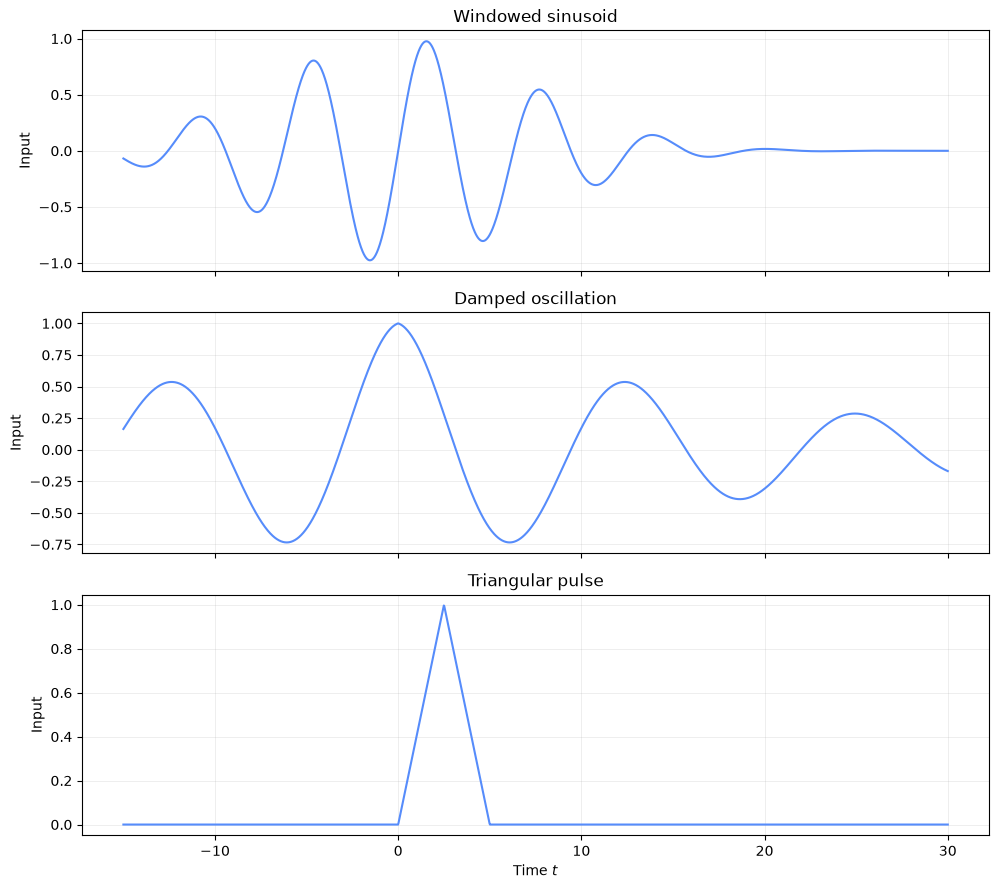

In [7]:
def windowed_sinusoid(time: np.ndarray) -> np.ndarray:
    return np.exp(-0.01 * time**2) * np.sin(time)

def damped_oscillation(time: np.ndarray) -> np.ndarray:
    return np.exp(-0.05 * np.abs(time)) * np.cos(0.5 * time)

def triangular_pulse(time: np.ndarray) -> np.ndarray:
    return np.maximum(
        1.0 - np.abs(time - 2.5) / 2.5,
        0.0,
    )

input_functions = {
    "Windowed sinusoid": windowed_sinusoid,
    "Damped oscillation": damped_oscillation,
    "Triangular pulse": triangular_pulse,
}

input_grid = np.linspace(-15.0, 30.0, 2000)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for ax, (name, input_function) in zip(
    axes,
    input_functions.items(),
):
    ax.plot(input_grid, input_function(input_grid))
    ax.set_title(name)
    ax.set_ylabel("Input")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time $t$")
fig.tight_layout()
plt.show()

**Figure 6.** Three bounded continuous input signals that vanish at infinity. Each satisfies \(\|x\|_\infty\le 1\).

## 11. Functional outputs

We compare

$$
H_t(x)
=
\int_0^\infty \rho(s)x(t-s)\,ds
$$

with

$$
\widehat H_t(x)
=
\int_0^\infty \widehat\rho_m(s)x(t-s)\,ds
$$

for the polynomial target and its learned width-\(10\) approximation.

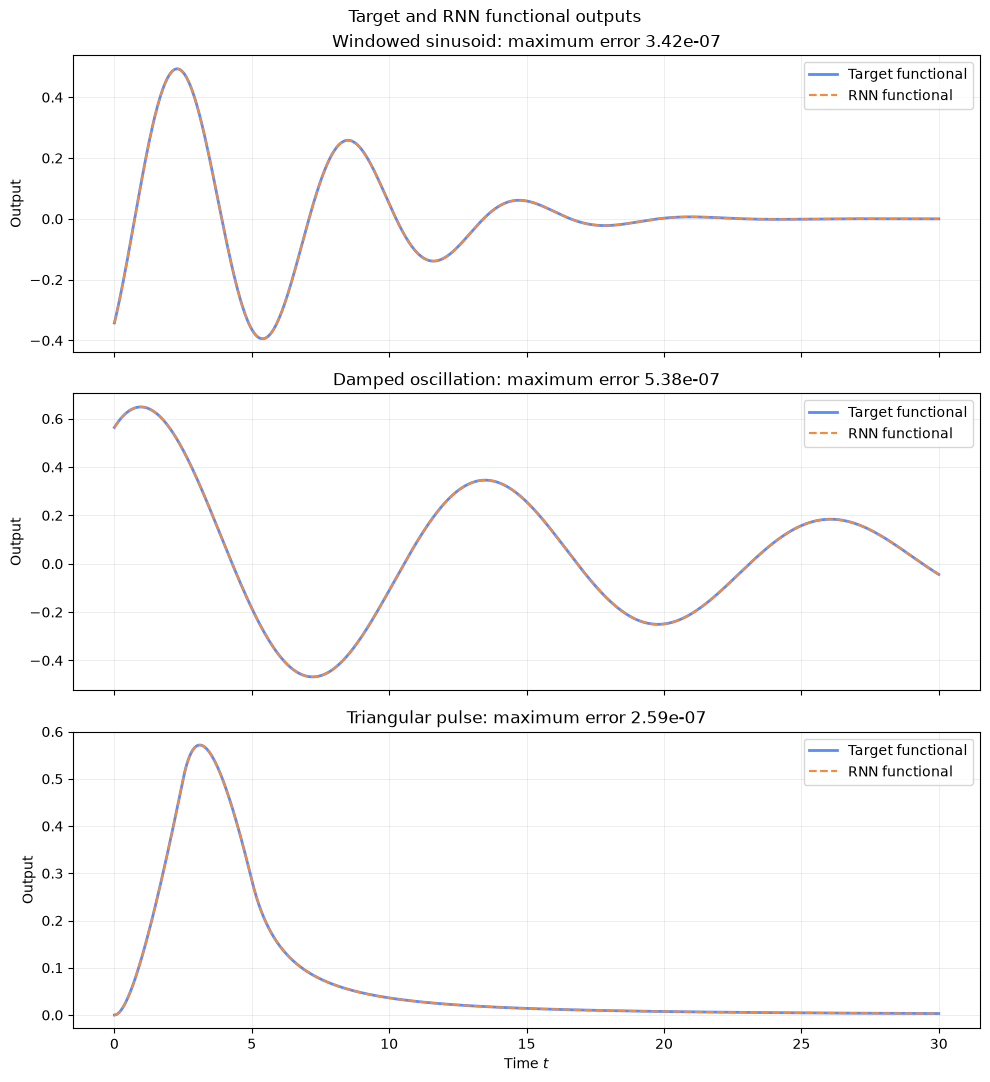

In [8]:
output_width = 10
output_coefficients, output_rates = learned_solutions[output_width]

evaluation_times = np.linspace(0.0, 30.0, 1000)
memory_grid = np.concatenate(
    [
        np.linspace(0.0, 20.0, 6000, endpoint=False),
        np.geomspace(20.0, 500.0, 4000),
    ]
)

target_kernel_values = exp.polynomial_kernel(memory_grid)
approximation_kernel_values = exp.evaluate_exponential_sum(
    memory_grid,
    output_coefficients,
    output_rates,
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 11),
    sharex=True,
)

for ax, (name, input_function) in zip(
    axes,
    input_functions.items(),
):
    target_output = exp.apply_kernel(
        evaluation_times,
        memory_grid,
        target_kernel_values,
        input_function,
    )
    approximation_output = exp.apply_kernel(
        evaluation_times,
        memory_grid,
        approximation_kernel_values,
        input_function,
    )

    maximum_error = np.max(
        np.abs(target_output - approximation_output)
    )

    ax.plot(
        evaluation_times,
        target_output,
        linewidth=2,
        label="Target functional",
    )
    ax.plot(
        evaluation_times,
        approximation_output,
        linestyle="--",
        label="RNN functional",
    )
    ax.set_title(
        f"{name}: maximum error {maximum_error:.2e}"
    )
    ax.set_ylabel("Output")
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time $t$")
fig.suptitle("Target and RNN functional outputs")
fig.tight_layout()
plt.show()

**Figure 7.** Outputs of the target functional and the learned RNN functional for three inputs in \(C_0(\mathbb R)\). The curves are nearly indistinguishable for the chosen examples.

These plots illustrate particular inputs only. The \(L^1\)-kernel estimate is the stronger statement because it controls the output error uniformly over the unit ball of \(\mathcal X\).

## 12. Discussion

### What is inherited from Theorem 7

- admissible functional families admit a common \(L^1\)-kernel representation;
- stable linear CT-RNNs generate matrix-exponential kernels;
- an \(L^1\)-kernel approximation controls the operator error uniformly over bounded inputs.

### What is observed numerically

- finite exponential sums approximate the selected kernels increasingly well at moderate widths;
- learned decay rates improve the approximation of the polynomial target;
- small learned rates are used to represent longer time scales;
- very large fixed exponential bases become severely ill-conditioned;
- the induced outputs are close for the three displayed inputs.

### What is not established

- the experiments do not prove universal approximation;
- they do not yield an approximation rate;
- the nonlinear solver is not guaranteed to find a global optimum;
- only diagonal stable state matrices are considered.

## 13. Takeaways

> **Takeaway 1 — Kernel reduction is the central step.**  
> In the linear time-homogeneous setting, functional approximation reduces to approximation of one convolution kernel.

> **Takeaway 2 — Exponential sums are diagonal-RNN kernels.**  
> For \(W=-\operatorname{diag}(\lambda_1,\ldots,\lambda_m)\), the RNN kernel is \(\sum_j a_j e^{-\lambda_j t}\).

> **Takeaway 3 — Learned time scales improve flexibility.**  
> Optimizing the decay rates adapts the model to the memory structure of the target.

> **Takeaway 4 — Expressivity and conditioning are distinct.**  
> Increasing width enlarges the model class, but the discrete fitting problem can become numerically unstable.

> **Takeaway 5 — Theorem 7 is qualitative.**  
> It guarantees existence for every \(\varepsilon>0\), but does not specify the required width. Approximation rates are addressed by Theorem 10.

## 14. Limitations and possible extensions

- scalar kernels only;
- diagonal stable state matrices only;
- one nonlinear initialization per width;
- discrete \(L^2\)-fitting but \(L^1\)-evaluation;
- finite numerical interval plus analytic tail bounds;
- only two representative target kernels.

Possible extensions include multiple initializations, vector-valued inputs, general stable matrices \(W\), and direct numerical implementation of the constructive rates \(\lambda_j=j\) used in the proof.

## 15. References

Li, Zhong, Jiequn Han, Weinan E, and Qianxiao Li. 2022.  
“Approximation and Optimization Theory for Linear Continuous-Time Recurrent Neural Networks.”  
*Journal of Machine Learning Research* 23 (42): 1–85.

```bibtex
@article{li2022approximation,
  author  = {Li, Zhong and Han, Jiequn and E, Weinan and Li, Qianxiao},
  title   = {Approximation and Optimization Theory for Linear Continuous-Time Recurrent Neural Networks},
  journal = {Journal of Machine Learning Research},
  year    = {2022},
  volume  = {23},
  number  = {42},
  pages   = {1--85},
  url     = {https://jmlr.org/papers/v23/21-0368.html}
}
```